<a href="https://colab.research.google.com/github/Abdallah-Osama-cpp/heart-disease-prediction/blob/main/Copy_of_Heart_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('/content/train_data.csv') # train data
dt = pd.read_csv('/content/test_data.csv')  # test data

**DATA EXPLORE**

In [7]:
df.head(10)

,id,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,work_type,smoking_status,Heart Disease
0,1,70.0,Female,4,130,322,0,2,109,0,2.4,2,3,3,Private,formerly smoked,Yes
1,2,67.0,Male,3,115,564,0,2,160,0,1.6,2,0,7,Self-employed,never smoked,No
2,3,57.0,Female,2,124,261,0,0,141,0,0.3,1,0,7,Private,never smoked,Yes
3,4,64.0,Female,4,128,263,0,0,105,1,0.2,2,1,7,Private,smokes,No
4,5,74.0,Male,2,120,269,0,2,121,1,0.2,1,1,3,Self-employed,never smoked,No
5,6,65.0,Female,4,120,177,0,0,140,0,0.4,1,0,7,Private,formerly smoked,No
6,7,56.0,Female,3,130,256,1,2,142,1,0.6,2,1,6,Private,never smoked,Yes
7,8,59.0,Female,4,110,239,0,2,142,1,1.2,2,1,7,Private,never smoked,Yes
8,9,60.0,Female,4,140,293,0,2,170,0,1.2,2,2,7,Private,Unknown,Yes
9,10,63.0,Male,4,150,407,0,2,154,0,4.0,2,3,7,Private,Unknown,Yes


In [8]:
dt.head(10)

,id,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,work_type,smoking_status,Heart Disease
0,225,41.0,Male,2,130,204,0,2,172,0,1.4,1,0,3,Private,smokes,No
1,226,63.0,Male,3,135,252,0,2,172,0,0.0,1,0,3,Self-employed,never smoked,No
2,227,51.0,Female,3,94,227,0,0,154,1,0.0,1,1,7,Private,smokes,No
3,228,54.0,Female,3,120,258,0,2,147,0,0.4,2,0,7,Self-employed,smokes,No
4,229,44.0,Female,2,120,220,0,0,170,0,0.0,1,0,3,Govt_job,never smoked,No
5,230,54.0,Female,4,110,239,0,0,126,1,2.8,2,1,7,Private,smokes,Yes
6,231,65.0,Female,4,135,254,0,2,127,0,2.8,2,1,7,Private,never smoked,Yes
7,232,57.0,Female,3,150,168,0,0,174,0,1.6,1,0,3,Govt_job,formerly smoked,No
8,233,63.0,Female,4,130,330,1,2,132,1,1.8,1,3,7,Govt_job,smokes,Yes
9,235,35.0,Male,4,138,183,0,0,182,0,1.4,1,0,3,Private,smokes,No


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       224 non-null    int64  
 1   Age                      220 non-null    float64
 2   Gender                   218 non-null    object 
 3   Chest pain type          224 non-null    int64  
 4   BP                       224 non-null    int64  
 5   Cholesterol              224 non-null    int64  
 6   FBS over 120             224 non-null    int64  
 7   EKG results              224 non-null    int64  
 8   Max HR                   224 non-null    int64  
 9   Exercise angina          224 non-null    int64  
 10  ST depression            224 non-null    float64
 11  Slope of ST              224 non-null    int64  
 12  Number of vessels fluro  224 non-null    int64  
 13  Thallium                 224 non-null    int64  
 14  work_type                2

In [10]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       56 non-null     int64  
 1   Age                      54 non-null     float64
 2   Gender                   56 non-null     object 
 3   Chest pain type          56 non-null     int64  
 4   BP                       56 non-null     int64  
 5   Cholesterol              56 non-null     int64  
 6   FBS over 120             56 non-null     int64  
 7   EKG results              56 non-null     int64  
 8   Max HR                   56 non-null     int64  
 9   Exercise angina          56 non-null     int64  
 10  ST depression            56 non-null     float64
 11  Slope of ST              56 non-null     int64  
 12  Number of vessels fluro  56 non-null     int64  
 13  Thallium                 56 non-null     int64  
 14  work_type                54 

In [11]:
df.describe()

,id,Age,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,224.000000,220.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000
mean,112.138393,54.550000,3.187500,130.700893,248.044643,0.151786,1.026786,149.245536,0.357143,1.025446,1.602679,0.696429,4.633929
std,64.671738,9.266833,0.961419,18.021034,51.895011,0.359617,0.997394,23.834396,0.480231,1.121668,0.626895,0.940749,1.936182
min,1.000000,29.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,56.750000,47.750000,3.000000,120.000000,212.000000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,112.500000,55.000000,3.000000,130.000000,242.500000,0.000000,2.000000,154.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,168.250000,61.250000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.800000,2.000000,1.000000,7.000000
max,224.000000,77.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,5.600000,3.000000,3.000000,7.000000


In [12]:
dt.describe()

,id,Age,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,56.000000,54.000000,56.000000,56.000000,56.000000,56.000000,56.00000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000
mean,252.517857,53.722222,3.178571,133.625000,250.321429,0.125000,1.00000,152.696429,0.250000,1.153571,1.517857,0.571429,4.785714
std,16.289418,8.995631,0.876089,16.447782,49.633239,0.333712,1.00905,20.639697,0.436931,1.183364,0.602753,0.931414,1.951357
min,225.000000,35.000000,1.000000,94.000000,164.000000,0.000000,0.00000,97.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,238.750000,45.500000,3.000000,120.000000,210.500000,0.000000,0.00000,141.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,252.500000,54.000000,3.000000,132.000000,253.500000,0.000000,1.00000,154.500000,0.000000,1.000000,1.000000,0.000000,3.000000
75%,266.250000,60.750000,4.000000,140.000000,283.250000,0.000000,2.00000,170.250000,0.250000,1.600000,2.000000,1.000000,7.000000
max,280.000000,71.000000,4.000000,180.000000,353.000000,1.000000,2.00000,190.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [13]:
df = df.drop(columns=['id'])
dt = dt.drop(columns=['id'])

**HANDLING NULLS**

In [14]:
train_age_median = df['Age'].median()
train_gender_mode = df['Gender'].mode()[0]
train_work_mode = df['work_type'].mode()[0]
train_smoking_mode = df['smoking_status'].mode()[0]

df['Age'].fillna(train_age_median, inplace=True)
df['Gender'].fillna(train_gender_mode, inplace=True)
df['work_type'].fillna(train_work_mode, inplace=True)
df['smoking_status'].fillna(train_smoking_mode, inplace=True)

dt['Age'].fillna(train_age_median, inplace=True)
dt['work_type'].fillna(train_work_mode, inplace=True)
dt['smoking_status'].fillna(train_smoking_mode, inplace=True)

/tmp/ipykernel_6644/3870240921.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(train_age_median, inplace=True)
/tmp/ipykernel_6644/3870240921.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      224 non-null    float64
 1   Gender                   224 non-null    object 
 2   Chest pain type          224 non-null    int64  
 3   BP                       224 non-null    int64  
 4   Cholesterol              224 non-null    int64  
 5   FBS over 120             224 non-null    int64  
 6   EKG results              224 non-null    int64  
 7   Max HR                   224 non-null    int64  
 8   Exercise angina          224 non-null    int64  
 9   ST depression            224 non-null    float64
 10  Slope of ST              224 non-null    int64  
 11  Number of vessels fluro  224 non-null    int64  
 12  Thallium                 224 non-null    int64  
 13  work_type                224 non-null    object 
 14  smoking_status           2

In [16]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      56 non-null     float64
 1   Gender                   56 non-null     object 
 2   Chest pain type          56 non-null     int64  
 3   BP                       56 non-null     int64  
 4   Cholesterol              56 non-null     int64  
 5   FBS over 120             56 non-null     int64  
 6   EKG results              56 non-null     int64  
 7   Max HR                   56 non-null     int64  
 8   Exercise angina          56 non-null     int64  
 9   ST depression            56 non-null     float64
 10  Slope of ST              56 non-null     int64  
 11  Number of vessels fluro  56 non-null     int64  
 12  Thallium                 56 non-null     int64  
 13  work_type                56 non-null     object 
 14  smoking_status           56 

**ENCODING**

In [17]:
df.head()

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,work_type,smoking_status,Heart Disease
0,70.0,Female,4,130,322,0,2,109,0,2.4,2,3,3,Private,formerly smoked,Yes
1,67.0,Male,3,115,564,0,2,160,0,1.6,2,0,7,Self-employed,never smoked,No
2,57.0,Female,2,124,261,0,0,141,0,0.3,1,0,7,Private,never smoked,Yes
3,64.0,Female,4,128,263,0,0,105,1,0.2,2,1,7,Private,smokes,No
4,74.0,Male,2,120,269,0,2,121,1,0.2,1,1,3,Self-employed,never smoked,No


In [18]:
df['Gender'].unique()


array(['Female', 'Male'], dtype=object)

In [19]:
dt['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [20]:
df['smoking_status'].unique()


array(['formerly smoked', 'never smoked', 'smokes', 'Unknown'],
      dtype=object)

In [21]:
dt['smoking_status'].unique()

array(['smokes', 'never smoked', 'formerly smoked', 'Unknown'],
      dtype=object)

In [22]:
df['work_type'].unique()


array(['Private', 'Self-employed', 'Govt_job', 'children'], dtype=object)

In [23]:
dt['work_type'].unique()

array(['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'],
      dtype=object)

In [24]:
df['Heart Disease'].unique()


array(['Yes', 'No'], dtype=object)

In [25]:
dt['Heart Disease'].unique()

array(['No', 'Yes'], dtype=object)

In [26]:
df['Heart Disease'] = df['Heart Disease'].map({'No': 0, 'Yes': 1})
dt['Heart Disease'] = dt['Heart Disease'].map({'No': 0, 'Yes': 1})

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
dt['Gender'] = dt['Gender'].map({'Male': 1, 'Female': 0})

df = pd.get_dummies(df, columns=['smoking_status', 'work_type'], drop_first=False)
dt = pd.get_dummies(dt, columns=['smoking_status', 'work_type'], drop_first=False)

dt = dt.reindex(columns=df.columns, fill_value=0)

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
dt[bool_cols] = dt[bool_cols].astype(int)


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             224 non-null    float64
 1   Gender                          224 non-null    int64  
 2   Chest pain type                 224 non-null    int64  
 3   BP                              224 non-null    int64  
 4   Cholesterol                     224 non-null    int64  
 5   FBS over 120                    224 non-null    int64  
 6   EKG results                     224 non-null    int64  
 7   Max HR                          224 non-null    int64  
 8   Exercise angina                 224 non-null    int64  
 9   ST depression                   224 non-null    float64
 10  Slope of ST                     224 non-null    int64  
 11  Number of vessels fluro         224 non-null    int64  
 12  Thallium                        224 

In [28]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             56 non-null     float64
 1   Gender                          56 non-null     int64  
 2   Chest pain type                 56 non-null     int64  
 3   BP                              56 non-null     int64  
 4   Cholesterol                     56 non-null     int64  
 5   FBS over 120                    56 non-null     int64  
 6   EKG results                     56 non-null     int64  
 7   Max HR                          56 non-null     int64  
 8   Exercise angina                 56 non-null     int64  
 9   ST depression                   56 non-null     float64
 10  Slope of ST                     56 non-null     int64  
 11  Number of vessels fluro         56 non-null     int64  
 12  Thallium                        56 non

In [29]:
df.head()

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,...,Thallium,Heart Disease,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children
0,70.0,0,4,130,322,0,2,109,0,2.4,...,3,1,0,1,0,0,0,1,0,0
1,67.0,1,3,115,564,0,2,160,0,1.6,...,7,0,0,0,1,0,0,0,1,0
2,57.0,0,2,124,261,0,0,141,0,0.3,...,7,1,0,0,1,0,0,1,0,0
3,64.0,0,4,128,263,0,0,105,1,0.2,...,7,0,0,0,0,1,0,1,0,0
4,74.0,1,2,120,269,0,2,121,1,0.2,...,3,0,0,0,1,0,0,0,1,0


**Separate features (X) and target (y)**

In [30]:
X_train = df.drop('Heart Disease', axis=1)
y_train = df['Heart Disease']

X_test = dt.drop('Heart Disease', axis=1)
y_test = dt['Heart Disease']

**Visualizing Outliers with Box Plots**

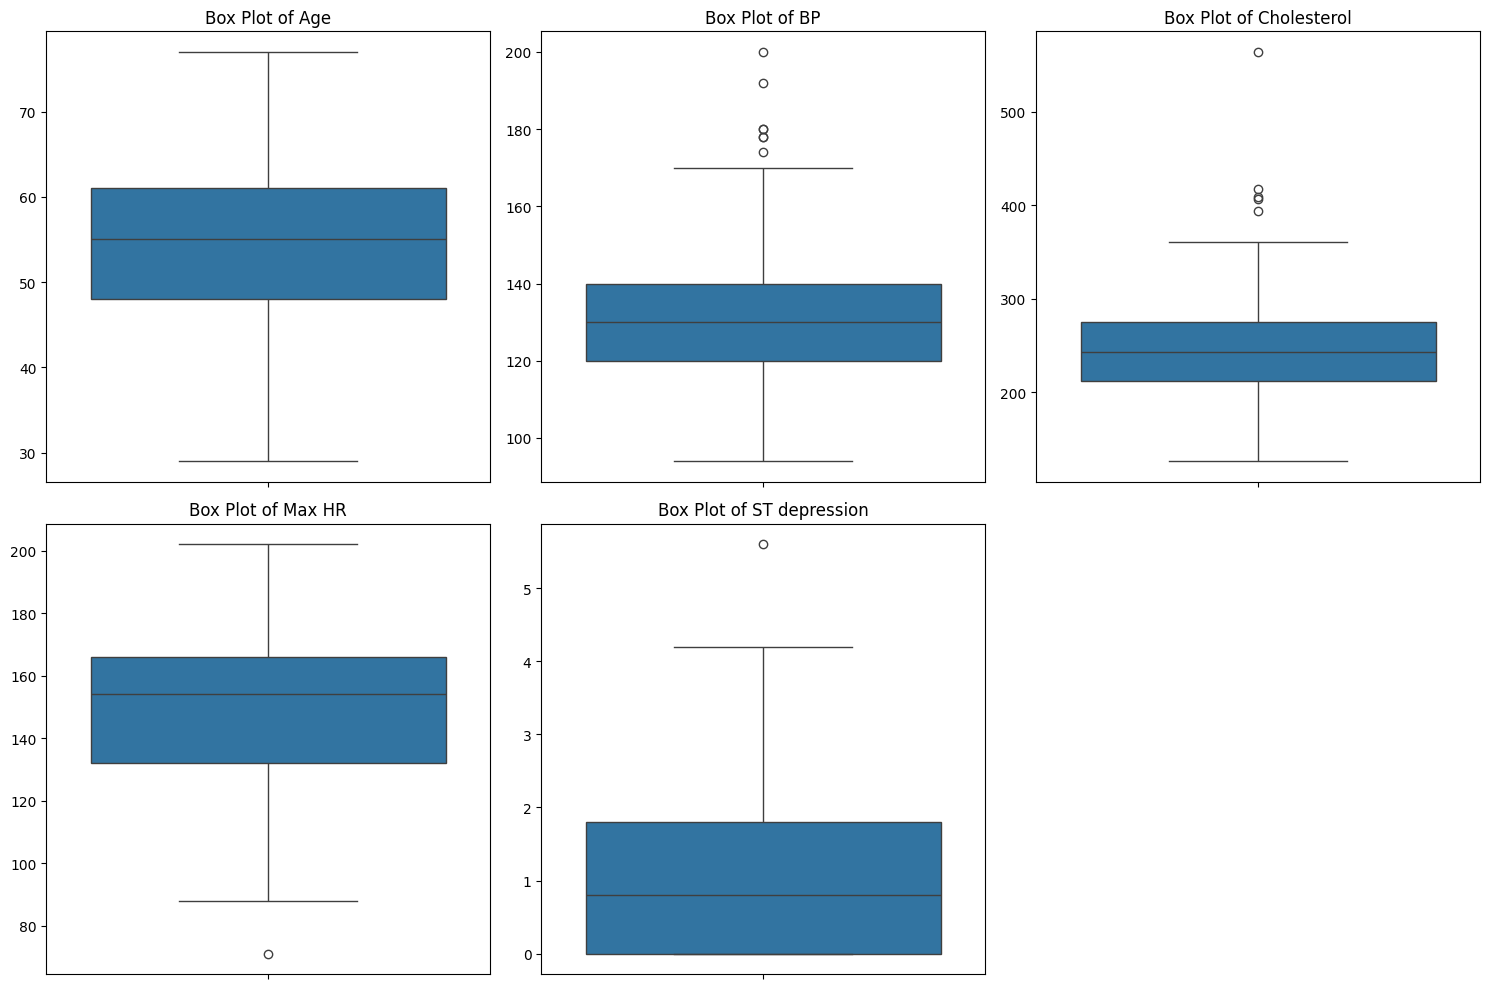

In [31]:
numerical_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.boxplot(y=X_train[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

**Identifying Outlier Indices using IQR**

In [32]:
outlier_indices = {}
for col in numerical_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    col_outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)].index.tolist()
    outlier_indices[col] = col_outliers

    print(f"Column: {col}")
    print(f"  Number of outliers: {len(col_outliers)}")
    print(f"  Outlier indices: {col_outliers}\n")

Column: Age
  Number of outliers: 0
  Outlier indices: []

Column: BP
  Number of outliers: 7
  Outlier indices: [58, 87, 110, 117, 153, 168, 174]

Column: Cholesterol
  Number of outliers: 5
  Outlier indices: [1, 9, 52, 190, 197]

Column: Max HR
  Number of outliers: 1
  Outlier indices: [101]

Column: ST depression
  Number of outliers: 1
  Outlier indices: [165]



**Capping Outliers using IQR**

In [33]:
for col in numerical_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers in X_train
    X_train[col] = X_train[col].clip(lower=lower_bound, upper=upper_bound)

    # Cap outliers in X_test using bounds from X_train
    X_test[col] = X_test[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers capped successfully in X_train and X_test.")

display(X_train.head())
display(X_test.head())

Outliers capped successfully in X_train and X_test.


,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,...,Number of vessels fluro,Thallium,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children
0,70.0,0,4,130,322.0,0,2,109,0,2.4,...,3,3,0,1,0,0,0,1,0,0
1,67.0,1,3,115,369.5,0,2,160,0,1.6,...,0,7,0,0,1,0,0,0,1,0
2,57.0,0,2,124,261.0,0,0,141,0,0.3,...,0,7,0,0,1,0,0,1,0,0
3,64.0,0,4,128,263.0,0,0,105,1,0.2,...,1,7,0,0,0,1,0,1,0,0
4,74.0,1,2,120,269.0,0,2,121,1,0.2,...,1,3,0,0,1,0,0,0,1,0


,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,...,Number of vessels fluro,Thallium,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children
0,41.0,1,2,130,204,0,2,172,0,1.4,...,0,3,0,0,0,1,0,1,0,0
1,63.0,1,3,135,252,0,2,172,0,0.0,...,0,3,0,0,1,0,0,0,1,0
2,51.0,0,3,94,227,0,0,154,1,0.0,...,1,7,0,0,0,1,0,1,0,0
3,54.0,0,3,120,258,0,2,147,0,0.4,...,0,7,0,0,0,1,0,0,1,0
4,44.0,0,2,120,220,0,0,170,0,0.0,...,0,3,0,0,1,0,1,0,0,0


**Visualizing Outliers after Capping with Box Plots**

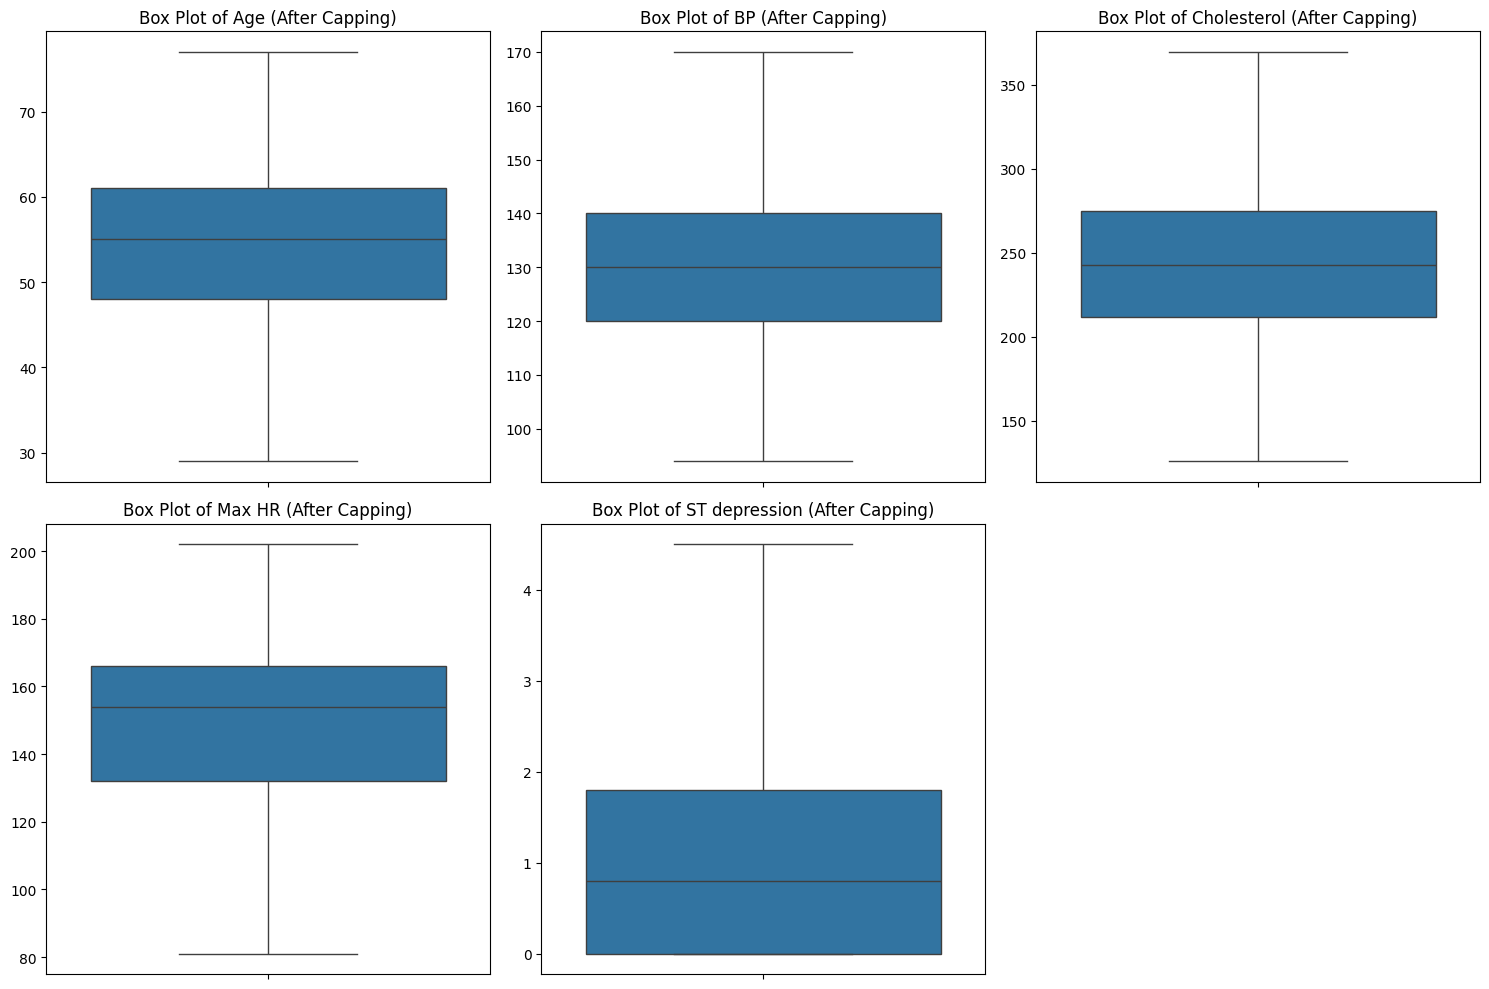

In [34]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.boxplot(y=X_train[col])
    plt.title(f'Box Plot of {col} (After Capping)')
    plt.ylabel('')
plt.tight_layout()
plt.show()

**Scaling Numerical Features**

In [35]:


scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

display(X_train.head())

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,...,Number of vessels fluro,Thallium,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children
0,1.685249,0,4,-0.017245,1.642873,0,2,-1.704092,0,1.252522,...,3,3,0,1,0,0,0,1,0,0
1,1.357846,1,3,-0.908676,2.676621,0,2,0.452977,0,0.526140,...,0,7,0,0,1,0,0,0,1,0
2,0.266502,0,2,-0.373818,0.315322,0,0,-0.350637,0,-0.654230,...,0,7,0,0,1,0,0,1,0,0
3,1.030443,0,4,-0.136102,0.358849,0,0,-1.873274,1,-0.745027,...,1,7,0,0,0,1,0,1,0,0
4,2.121786,1,2,-0.611533,0.489427,0,2,-1.196546,1,-0.745027,...,1,3,0,0,1,0,0,0,1,0


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [37]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report)

y_pred = model.predict(X_test_scaled)
print("ress")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred):.4f}")

ress
  Accuracy  : 0.8750
  Precision : 0.9048
  Recall    : 0.7917
  F1-Score  : 0.8444


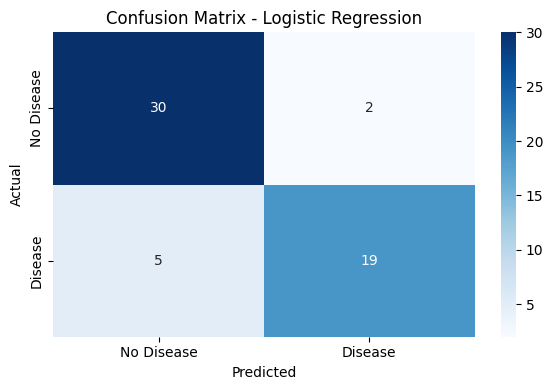

In [38]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as s

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
s.heatmap(cm, annot=True, fmt='d', cmap='Blues',
          xticklabels=['No Disease', 'Disease'],
          yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [39]:
import pandas as pd

results = []

C_values = [0.01, 0.1, 1, 10, 100]
iter_values = [100, 500, 1000]

for c in C_values:
    for it in iter_values:
        m = LogisticRegression(C=c, max_iter=it, random_state=42)
        m.fit(X_train_scaled, y_train)
        pred = m.predict(X_test_scaled)
        results.append({
            'C': c,
            'max_iter': it,
            'Accuracy': round(accuracy_score(y_test, pred), 4),
            'Recall': round(recall_score(y_test, pred), 4),
            'F1': round(f1_score(y_test, pred), 4)
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

best = results_df.loc[results_df['F1'].idxmax()]
print(f"\nbest C={best['C']}, max_iter={best['max_iter']}, F1={best['F1']}")

     C  max_iter  Accuracy  Recall     F1
  0.01       100    0.8750  0.7917 0.8444
  0.01       500    0.8750  0.7917 0.8444
  0.01      1000    0.8750  0.7917 0.8444
  0.10       100    0.8750  0.7917 0.8444
  0.10       500    0.8750  0.7917 0.8444
  0.10      1000    0.8750  0.7917 0.8444
  1.00       100    0.8750  0.7917 0.8444
  1.00       500    0.8750  0.7917 0.8444
  1.00      1000    0.8750  0.7917 0.8444
 10.00       100    0.8571  0.7500 0.8182
 10.00       500    0.8571  0.7500 0.8182
 10.00      1000    0.8571  0.7500 0.8182
100.00       100    0.8571  0.7500 0.8182
100.00       500    0.8571  0.7500 0.8182
100.00      1000    0.8571  0.7500 0.8182

best C=0.01, max_iter=100.0, F1=0.8444


In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, classification_report

 max_depth criterion  Accuracy  Precision  Recall     F1
       3.0      gini    0.8571     0.8636  0.7917 0.8261
       3.0   entropy    0.8571     0.8636  0.7917 0.8261
       5.0      gini    0.8214     0.8182  0.7500 0.7826
       5.0   entropy    0.7857     0.7727  0.7083 0.7391
       7.0      gini    0.7857     0.7500  0.7500 0.7500
       7.0   entropy    0.8036     0.7407  0.8333 0.7843
      10.0      gini    0.8036     0.7600  0.7917 0.7755
      10.0   entropy    0.8036     0.7600  0.7917 0.7755
       NaN      gini    0.8036     0.7600  0.7917 0.7755
       NaN   entropy    0.8036     0.7600  0.7917 0.7755
  Precision : 0.7600
  Recall    : 0.7917
  F1-Score  : 0.7755

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.84      0.81      0.83        32
     Disease       0.76      0.79      0.78        24

    accuracy                           0.80        56
   macro avg       0.80      0.80      0.80        56
weighted avg  

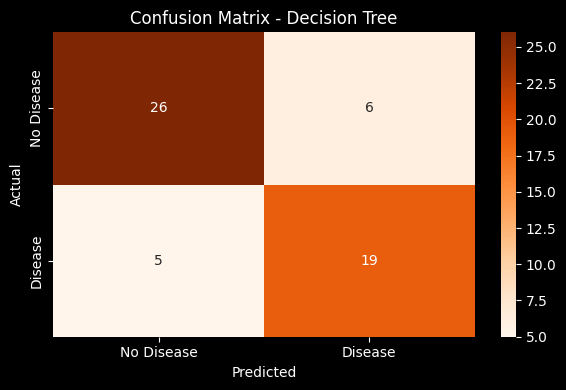

In [72]:
results_dt = []
for depth in [3, 5, 7, 10, None]:
    for crit in ['gini', 'entropy']:
        dt = DecisionTreeClassifier(max_depth=depth, criterion=crit, random_state=42)
        dt.fit(X_train_scaled, y_train)
        pred = dt.predict(X_test_scaled)
        results_dt.append({'max_depth': depth, 'criterion': crit,
            'Accuracy': round(accuracy_score(y_test, pred), 4),
            'Precision': round(precision_score(y_test, pred), 4),
            'Recall': round(recall_score(y_test, pred), 4),
            'F1': round(f1_score(y_test, pred), 4)})
print(pd.DataFrame(results_dt).to_string(index=False))

decision_tree_model = DecisionTreeClassifier(criterion = "entropy", random_state = 42)
decision_tree_model.fit(X_train_scaled, y_train)
y_predicted_by_decision_tree = decision_tree_model.predict(X_test_scaled)

accuracy_of_decision_tree = accuracy_score(y_test, y_predicted_by_decision_tree)
print(f"  Precision : {precision_score(y_test, y_predicted_by_decision_tree):.4f}")
print(f"  Recall    : {recall_score(y_test, y_predicted_by_decision_tree):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_predicted_by_decision_tree):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_predicted_by_decision_tree, target_names=['No Disease', 'Disease']))
print("Accuracy of decision tree model:", accuracy_of_decision_tree)
cm_dt = confusion_matrix(y_test, y_predicted_by_decision_tree)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('tree_cm.png', bbox_inches='tight', dpi=300)
plt.show()


In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, classification_report, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
plt.style.use('dark_background')

# just picking randomly here until we do a grid search
svm_model = SVC(kernel='rbf', C=0.1, random_state=42)

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
accuracy_of_svm = accuracy_score(y_test, y_pred_svm)
# Change these 4 lines to use y_pred_svm instead:
print(f"  Precision : {precision_score(y_test, y_pred_svm):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_svm):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm, target_names=['No Disease', 'Disease']))

print("--- SVM Model Evaluation ---")
print("Accuracy: ", f"{accuracy_of_svm:.3f}")

  Precision : 0.7600
  Recall    : 0.7917
  F1-Score  : 0.7755
              precision    recall  f1-score   support

  No Disease       0.84      0.81      0.83        32
     Disease       0.76      0.79      0.78        24

    accuracy                           0.80        56
   macro avg       0.80      0.80      0.80        56
weighted avg       0.80      0.80      0.80        56

--- SVM Model Evaluation ---
Accuracy:  0.804


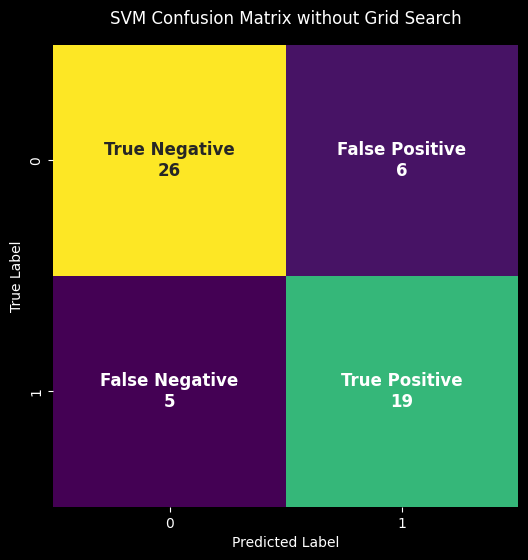

In [44]:
cm = confusion_matrix(y_test, y_pred_svm, labels=svm_model.classes_)

group_names = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
group_counts = [str(value) for value in cm.flatten()]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
labels = np.asarray(labels).reshape(2, 2)

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='viridis', cbar=False,
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_,
            ax=ax, annot_kws={"size": 12, "weight": "bold"})

plt.title("SVM Confusion Matrix without Grid Search", pad=15)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [45]:
# we use an algorithm called grid search to find the optimal values for our hyperparameters
# instead of just picking them randomly like i did above

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'] # added gamma to give the rbf/poly kernels more tuning options
}

svm_base = SVC(random_state=42)

svm_grid = GridSearchCV(estimator=svm_base, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# cv = 5 means we are doing 5-fold cross-validation
# n_jobs=-1 means we are using all available CPU cores to speed up the search process



In [46]:
svm_grid.fit(X_train, y_train)
y_pred_grid_search_svm = svm_grid.predict(X_test)
accuracy_of_grid_search_svm = accuracy_score(y_test, y_pred_grid_search_svm)
best_svm = svm_grid.best_estimator_

print("--- SVM Model Evaluation ---")
print("Best Hyperparameters Found:", svm_grid.best_params_)
print("Best Cross-Validation Accuracy: ", f"{accuracy_of_grid_search_svm:.3f}")

--- SVM Model Evaluation ---
Best Hyperparameters Found: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation Accuracy:  0.839


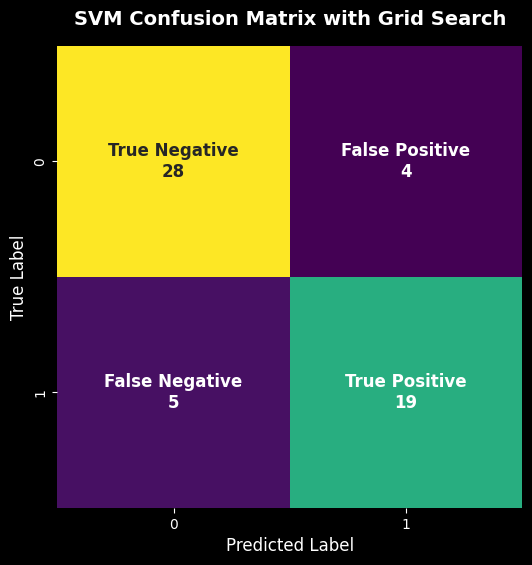

In [47]:
plt.style.use('dark_background')

cm = confusion_matrix(y_test, y_pred_grid_search_svm, labels=best_svm.classes_)

group_names = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
group_counts = [str(value) for value in cm.flatten()]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
labels = np.asarray(labels).reshape(2, 2)

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='viridis', cbar=False,
            xticklabels=best_svm.classes_, yticklabels=best_svm.classes_,
            ax=ax, annot_kws={"size": 12, "weight": "bold"})

plt.title("SVM Confusion Matrix with Grid Search", pad=15, fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

 n_estimators  max_depth  Accuracy  Precision  Recall     F1
           50        5.0    0.8214     0.8182  0.7500 0.7826
           50       10.0    0.8750     0.9048  0.7917 0.8444
           50       15.0    0.8750     0.9048  0.7917 0.8444
           50        NaN    0.8750     0.9048  0.7917 0.8444
          100        5.0    0.8393     0.8261  0.7917 0.8085
          100       10.0    0.8571     0.8636  0.7917 0.8261
          100       15.0    0.8750     0.9048  0.7917 0.8444
          100        NaN    0.8750     0.9048  0.7917 0.8444
          200        5.0    0.8571     0.8636  0.7917 0.8261
          200       10.0    0.8750     0.8696  0.8333 0.8511
          200       15.0    0.8750     0.8696  0.8333 0.8511
          200        NaN    0.8750     0.8696  0.8333 0.8511
          300        5.0    0.8750     0.9048  0.7917 0.8444
          300       10.0    0.8750     0.8696  0.8333 0.8511
          300       15.0    0.8750     0.8696  0.8333 0.8511
          300        NaN

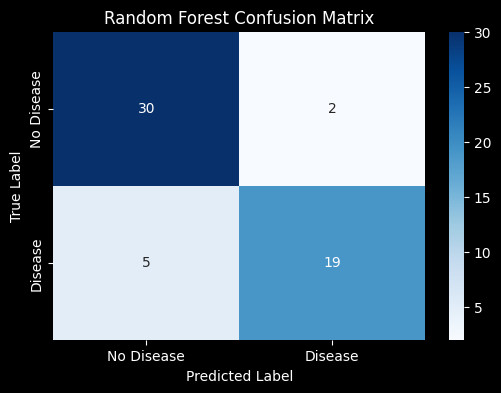

In [70]:
# Random Forest Model Evaluation
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
results_rf = []
for n_est in [50, 100, 200, 300]:
    for depth in [5, 10, 15, None]:
        rf = RandomForestClassifier(n_estimators=n_est, max_depth=depth, random_state=42)
        rf.fit(X_train_scaled, y_train)
        pred = rf.predict(X_test_scaled)
        results_rf.append({'n_estimators': n_est, 'max_depth': depth,
            'Accuracy': round(accuracy_score(y_test, pred), 4),
            'Precision': round(precision_score(y_test, pred), 4),
            'Recall': round(recall_score(y_test, pred), 4),
            'F1': round(f1_score(y_test, pred), 4)})
print(pd.DataFrame(results_rf).to_string(index=False))

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("--- Random Forest Model Evaluation ---")
print("Accuracy: ", f"{accuracy_rf:.3f}")
print(f"  Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Disease', 'Disease']))

# Plot Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title("Random Forest Confusion Matrix")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('random_cm.png', bbox_inches='tight', dpi=300)
plt.show()

 n_neighbors  weights  Accuracy  Precision  Recall     F1
           3  uniform    0.7679     0.7391  0.7083 0.7234
           3 distance    0.7500     0.7273  0.6667 0.6957
           5  uniform    0.7857     0.7727  0.7083 0.7391
           5 distance    0.7857     0.7727  0.7083 0.7391
           7  uniform    0.8214     0.7917  0.7917 0.7917
           7 distance    0.8214     0.7917  0.7917 0.7917
           9  uniform    0.8214     0.7917  0.7917 0.7917
           9 distance    0.8036     0.7826  0.7500 0.7660
          11  uniform    0.8036     0.7826  0.7500 0.7660
          11 distance    0.8036     0.7826  0.7500 0.7660
--- K-Nearest Neighbors Model Evaluation ---
Accuracy:  0.786
  Precision : 0.7727
  Recall    : 0.7083
  F1-Score  : 0.7391

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.79      0.84      0.82        32
     Disease       0.77      0.71      0.74        24

    accuracy                           0.79      

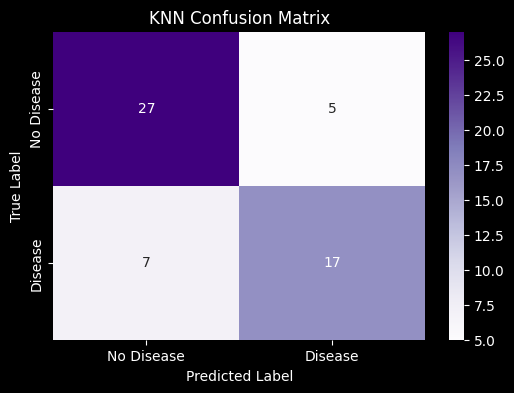

In [68]:
# K-Nearest Neighbors (KNN) Model Evaluation
from sklearn.neighbors import KNeighborsClassifier

results_knn = []
for k in [3, 5, 7, 9, 11]:
    for w in ['uniform', 'distance']:
        knn = KNeighborsClassifier(n_neighbors=k, weights=w)
        knn.fit(X_train_scaled, y_train)
        pred = knn.predict(X_test_scaled)
        results_knn.append({'n_neighbors': k, 'weights': w,
            'Accuracy': round(accuracy_score(y_test, pred), 4),
            'Precision': round(precision_score(y_test, pred), 4),
            'Recall': round(recall_score(y_test, pred), 4),
            'F1': round(f1_score(y_test, pred), 4)})
print(pd.DataFrame(results_knn).to_string(index=False))

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("--- K-Nearest Neighbors Model Evaluation ---")
print("Accuracy: ", f"{accuracy_knn:.3f}")
print(f"  Precision : {precision_score(y_test, y_pred_knn):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_knn):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_knn):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['No Disease', 'Disease']))

# Plot Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title("KNN Confusion Matrix")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('knn_cm.png', bbox_inches='tight', dpi=300)
plt.show()

 n_estimators  learning_rate  Accuracy  Precision  Recall     F1
           50           0.01    0.8750     0.9048  0.7917 0.8444
           50           0.05    0.8929     0.9091  0.8333 0.8696
           50           0.10    0.8571     0.8333  0.8333 0.8333
           50           0.20    0.8393     0.8000  0.8333 0.8163
          100           0.01    0.8750     0.9048  0.7917 0.8444
          100           0.05    0.8571     0.8333  0.8333 0.8333
          100           0.10    0.8571     0.8333  0.8333 0.8333
          100           0.20    0.8393     0.8000  0.8333 0.8163
          200           0.01    0.8929     0.9091  0.8333 0.8696
          200           0.05    0.8393     0.8000  0.8333 0.8163
          200           0.10    0.8393     0.8000  0.8333 0.8163
          200           0.20    0.8036     0.7407  0.8333 0.7843
          300           0.01    0.8750     0.8696  0.8333 0.8511
          300           0.05    0.8393     0.8000  0.8333 0.8163
          300           0

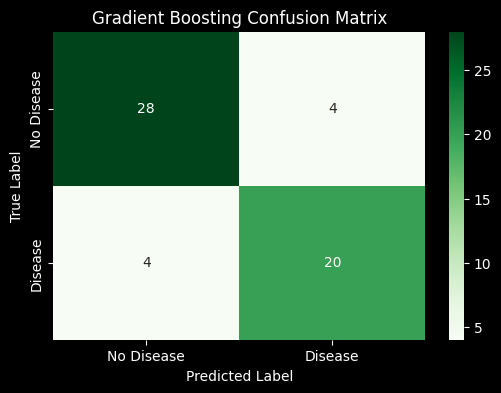

In [69]:
# Gradient Boosting Model Evaluation
from sklearn.ensemble import GradientBoostingClassifier
results_gb = []
for n_est in [50, 100, 200, 300]:
    for lr in [0.01, 0.05, 0.1, 0.2]:
        gb = GradientBoostingClassifier(n_estimators=n_est, learning_rate=lr, random_state=42)
        gb.fit(X_train_scaled, y_train)
        pred = gb.predict(X_test_scaled)
        results_gb.append({'n_estimators': n_est, 'learning_rate': lr,
            'Accuracy': round(accuracy_score(y_test, pred), 4),
            'Precision': round(precision_score(y_test, pred), 4),
            'Recall': round(recall_score(y_test, pred), 4),
            'F1': round(f1_score(y_test, pred), 4)})
print(pd.DataFrame(results_gb).to_string(index=False))

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_scaled, y_train)
y_pred_gb = gb_model.predict(X_test_scaled)
accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("--- Gradient Boosting Model Evaluation ---")
print("Accuracy: ", f"{accuracy_gb:.3f}")
print(f"  Precision : {precision_score(y_test, y_pred_gb):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_gb):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_gb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb, target_names=['No Disease', 'Disease']))

# Plot Confusion Matrix
cm_gb = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('gb_cm.png', bbox_inches='tight', dpi=300)
plt.show()

In [53]:
import joblib
import os

# Ensure the assets directory exists
os.makedirs('./assets', exist_ok=True)

# 1. Extract the Logistic Regression Model
# (Using the base 'model' variable from your code)
joblib.dump(model, '/content/logistic_regression.pkl')

# 2. Extract the Decision Tree Model
# (Using the 'decision_tree_model' variable)
joblib.dump(decision_tree_model, '/content/decision_tree.pkl')

# 3. Extract the Best SVM Model
# (Using the 'best_svm' variable from your Grid Search)
joblib.dump(best_svm, '/content/svm_model.pkl')

# 4. Extract the Best SVM Model
# (Using the 'best_svm' variable from your Grid Search)
joblib.dump(gb_model, '/content/gb_model.pkl')

# 5. Extract the Best SVM Model
# (Using the 'best_svm' variable from your Grid Search)
joblib.dump(knn_model, '/content/knn_model.pkl')

# 6. Extract the Best SVM Model
# (Using the 'best_svm' variable from your Grid Search)
joblib.dump(rf_model, '/content/rf_model.pkl')



# 4. Extract the Scaler (CRITICAL for preprocessing frontend data)
# (Using the 'scaler' variable)
joblib.dump(scaler, '/content/scaler.pkl')

print("✅ All 3 models and the scaler have been successfully extracted to the ./assets/ folder!")

✅ All 3 models and the scaler have been successfully extracted to the ./assets/ folder!
